In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [4]:
data = pd.read_csv("E:/Advance ML/Advance-Machine-Learning/Dataset/glass.csv")

In [6]:
data.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [8]:
X = data.drop("Type", axis = 1)
y = data["Type"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 23)

In [11]:
# Scaling Data

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
def knn_fun(train_x, train_y, test_x, k ):
    model = KNeighborsClassifier(n_neighbors = k)
    model.fit(train_x, train_y)
    pred = model.predict(test_x)
    return pred

In [13]:
import math
n = data.shape[0]
k_max = math.sqrt(n)
k_max

14.628738838327793

In [14]:
normal_accuracy = []
k_values = range(1,16)

for k in k_values:
    y_pred = knn_fun(X_train, y_train, X_test, k)
    accur = accuracy_score(y_test, y_pred)
    normal_accuracy.append(accur)



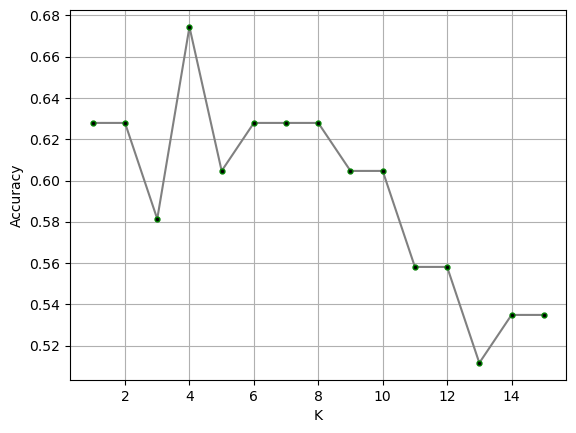

In [15]:

plt.plot(k_values, normal_accuracy, c = 'grey', marker = '.', ms = 7, mfc = 'black', mec ="green")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()